# sfig4 — Iso-Compute Heatmap, Additional Tasks (Supplementary Fig. S-4)

Full (L, K) heatmap with iso-compute contours for tasks not shown in main paper Fig. 3.
Panels: (a) age, (b) depression, (c) OSA.

**Data**: `heatmap_df_test.csv` per task, Transformer head.

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root ─��──────────────────────────────────────────────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Main utils (TBME style, data, panels)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS,
    TASK_LABEL, FONT_BASE, FONT_LABEL, FONT_TITLE, CTX_ORDER,
)
from utils.data import set_root, load_analysis, load_analysis_all_k, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
HEAD  = "transformer"
SPLIT = "test"
TASKS = ["age_class", "depression_extreme_binary", "osa_binary_apples_postqc"]

hmaps = {t: load_heatmap("phase0_v3", t, HEAD) for t in TASKS}
print("Heatmap sizes:", {t: len(v) for t, v in hmaps.items()})

Heatmap sizes: {'age_class': 81, 'depression_extreme_binary': 76, 'osa_binary_apples_postqc': 71}


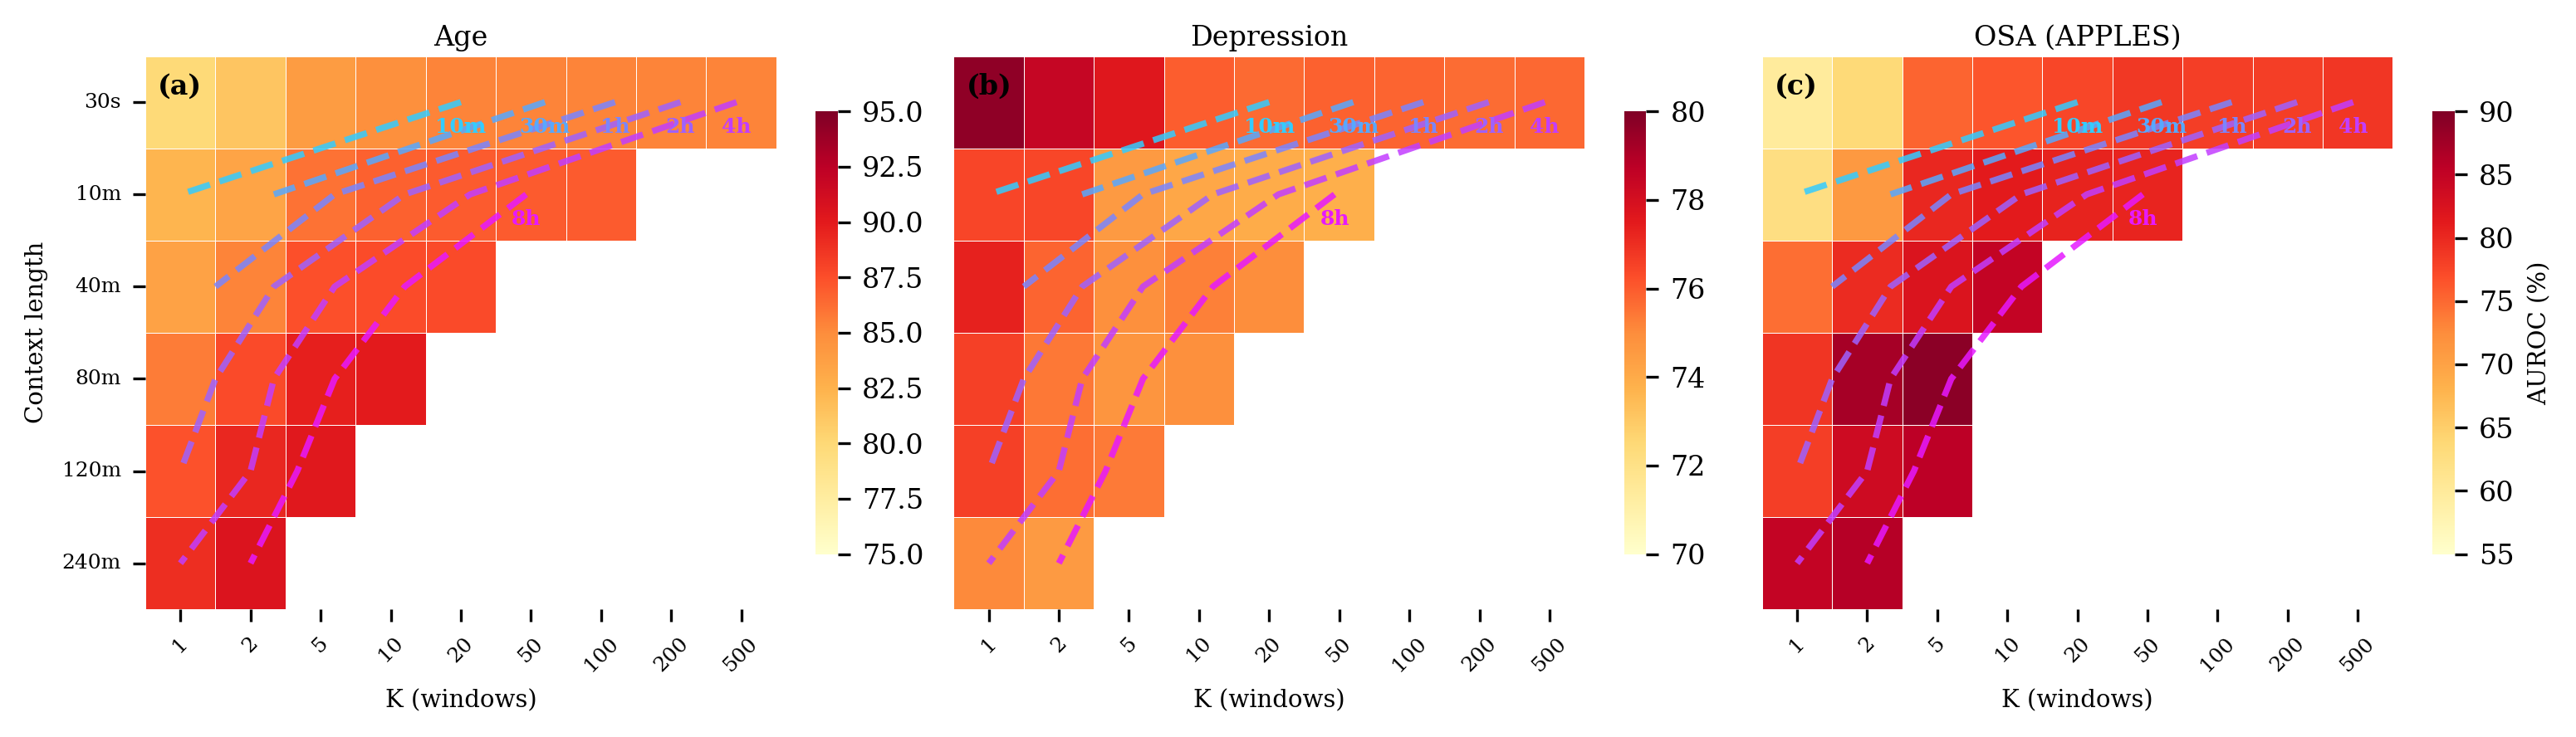

In [8]:
METRIC = "auroc"

fig, axes = plt.subplots(1, 3, figsize=(FULL_W * 1.5, 3.0))

for i, (ax, task) in enumerate(zip(axes, TASKS)):
    panels.heatmap_panel(ax, hmaps[task], col=METRIC,
                         show_ylabels=(i == 0),
                         show_cbar_label=(i == len(TASKS) - 1))
    ax.set_title(TASK_LABEL[task], fontsize=FONT_TITLE, pad=3)
    add_panel_label(ax, f"({chr(97 + i)})")

fig.tight_layout(h_pad=0.5, w_pad=-0.0)
plt.show()

In [9]:
save_figure(fig, FINAL_OUT, "sfig4_heatmap")
import shutil
shutil.copy(FINAL_OUT / "sfig4_heatmap.pdf",
            WORKSPACE_ROOT / "TBME_submission" / "sfig4_heatmap.pdf")
print("Saved + copied → TBME_submission/sfig4_heatmap.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig4_heatmap.pdf
Saved + copied → TBME_submission/sfig4_heatmap.pdf
